Loaded NRSur7dq4EmriRemnant fit.


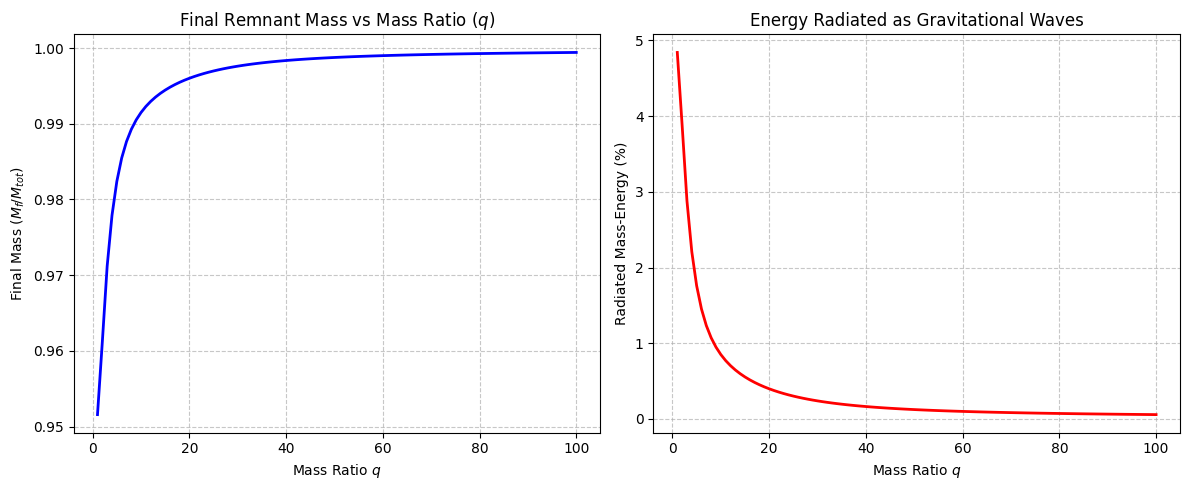

In [2]:
import surfinBH
import numpy as np
import matplotlib.pyplot as plt
import lal
lal.swig_redirect_standard_output_error(False)

fit = surfinBH.LoadFits('NRSur7dq4EmriRemnant')

q_values = np.linspace(1, 100, 100)

final_masses = []
radiated_energies = []

chiA = [0, 0, 0]
chiB = [0, 0, 0]


for q in q_values:

    mf, chif, vf, mf_err, chif_err, vf_err = fit.all(q, chiA, chiB)
    
    final_masses.append(mf)
    
    radiated_energies.append(1.0 - mf)


plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
plt.plot(q_values, final_masses, 'b-', linewidth=2)
plt.title('Final Remnant Mass vs Mass Ratio ($q$)')
plt.xlabel('Mass Ratio $q$')
plt.ylabel('Final Mass ($M_f / M_{tot}$)')
plt.grid(True, linestyle='--', alpha=0.7)


plt.subplot(1, 2, 2)
plt.plot(q_values, np.array(radiated_energies) * 100, 'r-', linewidth=2) 
plt.title('Energy Radiated as Gravitational Waves')
plt.xlabel('Mass Ratio $q$')
plt.ylabel('Radiated Mass-Energy (%)')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Loaded NRSur7dq4EmriRemnant fit.


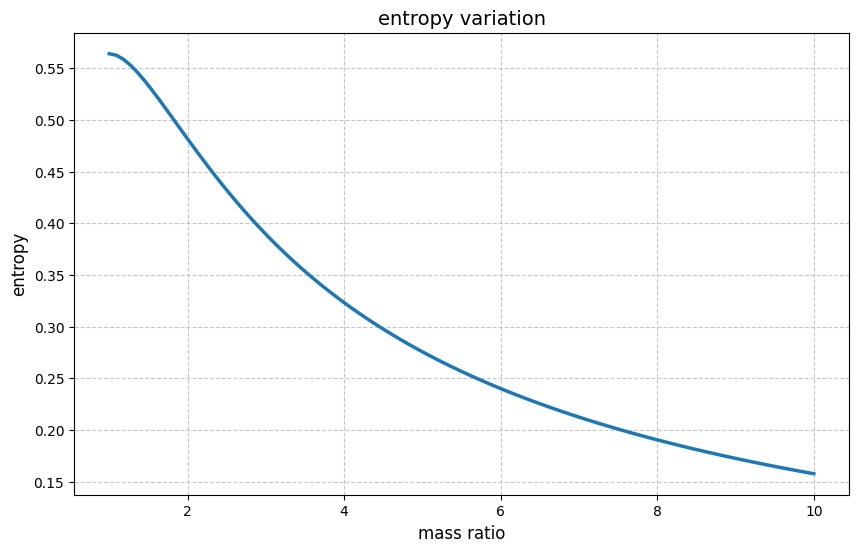

In [3]:
import surfinBH
import numpy as np
import lal
lal.swig_redirect_standard_output_error(False)


fit = surfinBH.LoadFits('NRSur7dq4EmriRemnant')

def calcola_area(M, chi_vec):
    chi = np.linalg.norm(chi_vec) 
    return 8 * np.pi * (M**2) * (1 + np.sqrt(1 - chi**2))


q_values = np.linspace(1,10,100)         
chiA = [0, 0, 0]  
chiB = [0, 0, 0] 
entropy = []

for q in q_values :
    m1 = q/(1+q)    
    m2 = 1/(1+q) 
    area_iniziale_totale = calcola_area(m1, chiA) + calcola_area(m2, chiB)
    mf, chif, vf, mf_err, chif_err, vf_err = fit.all(q, chiA, chiB)
    area_finale = calcola_area(mf, chif)
    variazione_percentuale = (area_finale - area_iniziale_totale) / area_iniziale_totale
    entropy.append(variazione_percentuale)


plt.figure(figsize=(10, 6))
plt.plot(q_values, entropy, linewidth=2.5)
plt.title('entropy variation', fontsize=14)
plt.xlabel('mass ratio', fontsize=12)
plt.ylabel('entropy', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show ()